In [1]:
#importacion de librerias
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#carga de archivo
df = pd.read_csv("C:/Users/K/Documents/curso_DA_chat/train.csv")

In [3]:
#Análisis rapido
#primeras columnas
print(df.head())
print("\n----------")
#información general
print(df.info())
print("\n----------")
#estadisticas rápidas
print(df.describe())
print("\n----------")
#Tamaño del dataset 
print(df.shape)
print("\n----------")
#columnas del dataset
print(df.columns)
print("\n----------")

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [4]:
#Limpieza
#conversion de datos a fecha
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
#Valores nulos
print(df.isnull().sum())
#valores duplicados
print("Duplicados: ", df.duplicated().sum())
#tipos de datos
print(df.dtypes)
#creacion columna de tiempo de envio
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Ship Date', 'Shipping Days']].head())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Duplicados:  0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object
  Order Date  Ship Dat

In [5]:
#Variables temporales 
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Day'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter
print(df[['Order Date', 'Year', 'Month', 'Month Name', 'Day', 'Quarter']].head())

  Order Date  Year  Month Month Name        Day  Quarter
0 2017-11-08  2017     11   November  Wednesday        4
1 2017-11-08  2017     11   November  Wednesday        4
2 2017-06-12  2017      6       June     Monday        2
3 2016-10-11  2016     10    October    Tuesday        4
4 2016-10-11  2016     10    October    Tuesday        4


In [6]:
#Análisis
#Ventas por region
ventas_region = (df.groupby('Region')['Sales'].sum().sort_values(ascending=False)).reset_index()
print(ventas_region)
#Top Categorías
ventas_categoria = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).head(10)
print(ventas_categoria)
#Ventas por Mes
ventas_mes = df.groupby('Month Name')['Sales'].sum().sort_values(ascending=False).reset_index()
print(ventas_mes)
#Top clientes
ventas_cliente = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(ventas_cliente)

    Region        Sales
0     West  710219.6845
1     East  669518.7260
2  Central  492646.9132
3    South  389151.4590
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
   Month Name        Sales
0    November  350161.7110
1    December  321480.1695
2   September  300103.4117
3     October  199496.2947
4       March  197573.5872
5      August  157315.9270
6         May  154086.7237
7        June  145837.5233
8        July  145535.6890
9       April  136283.0006
10    January   94291.6296
11   February   59371.1154
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


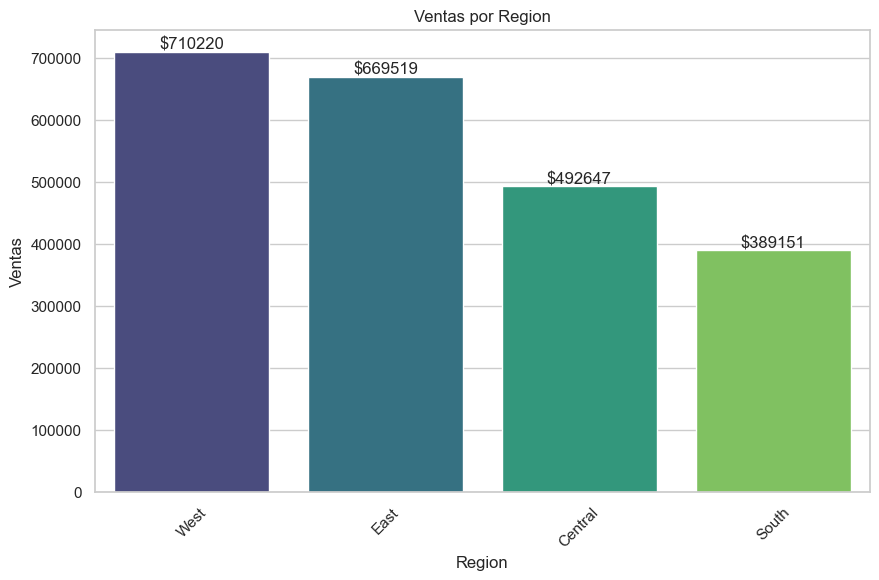

In [7]:
#graficas
#Regiones
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
ax = sns.barplot(data=ventas_region, x="Region", y="Sales", hue="Region", palette="viridis", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f')

plt.xticks(rotation=45)
plt.title("Ventas por Region")
plt.ylabel("Ventas")
plt.xlabel("Region")
plt.savefig("ventas_region.png")
plt.show()

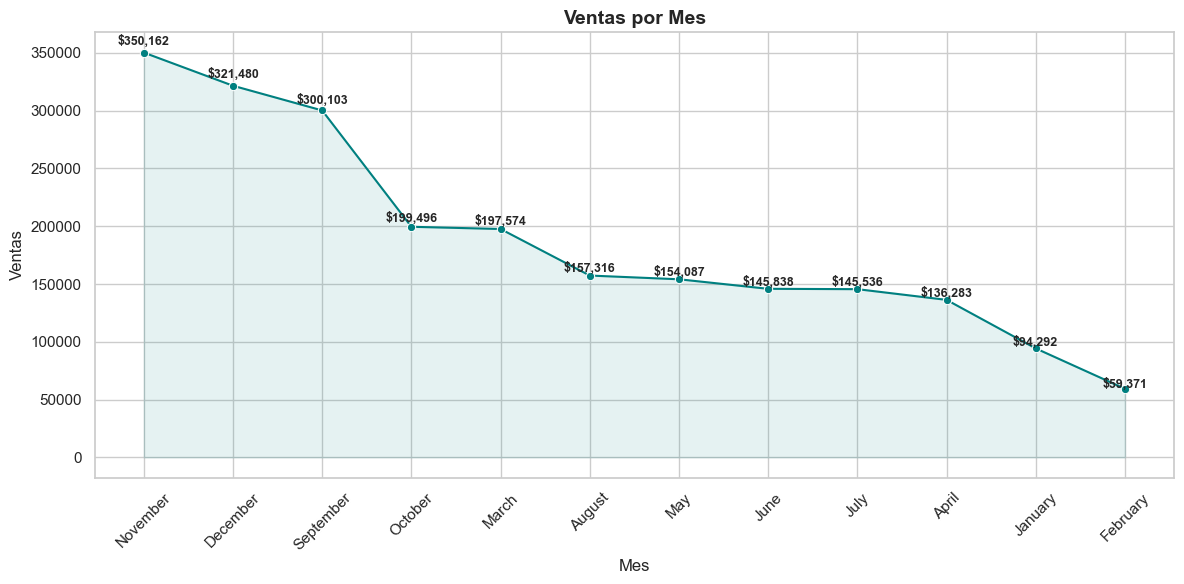

In [8]:
#ventas por Mes
fig, ax = plt.subplots(figsize=(12, 6))

orden_meses = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

sns.lineplot(data=ventas_mes, x="Month Name", y="Sales", marker="o", color="teal", ax=ax)

plt.fill_between(ventas_mes['Month Name'], ventas_mes['Sales'], alpha=0.1, color="teal")

for i, valor in enumerate(ventas_mes['Sales']):
    ax.text(i, valor + (valor * 0.02), f'${valor:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=45)
plt.title("Ventas por Mes", fontsize=14, fontweight='bold')
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.tight_layout()  
plt.savefig("ventas_mes.png")
plt.show()

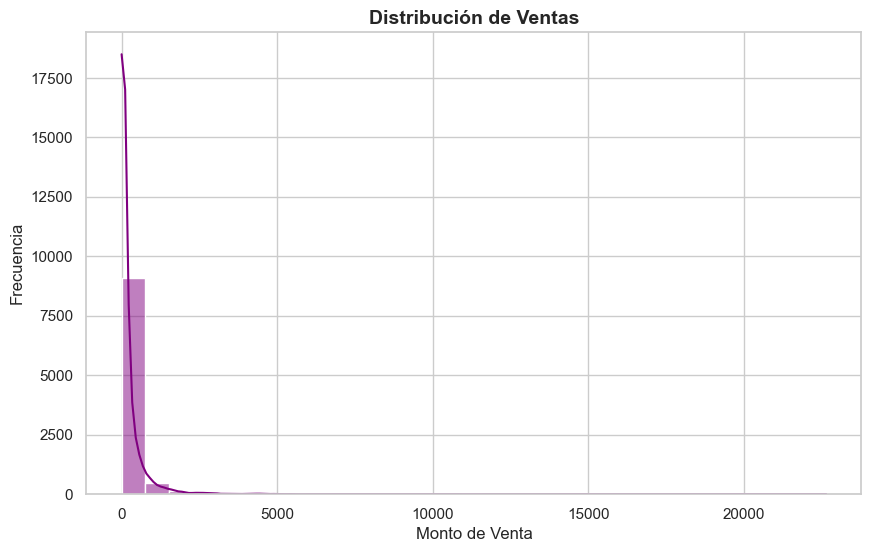

In [9]:
# Distribución de ventas (Histograma)
plt.figure(figsize=(10, 6))
# Aquí sí es correcto usar 'df' porque necesitas ver el detalle de cada venta individual
sns.histplot(df["Sales"], bins=30, kde=True, color="purple")
plt.title("Distribución de Ventas", fontsize=14, fontweight='bold')
plt.xlabel("Monto de Venta")
plt.ylabel("Frecuencia")
plt.savefig("distribucion.png")
plt.show()